# Volume Lalu Lintas Jalan Tol I-94 Minneapolis–Saint Paul Tahun 2012–2018  
#1
Nama : ALief Shoufiya Nafi  
NRP : 5027261006  
Nama : Anggito Abhinaya Sulistyo  
NRP : 5027261066  
Nama : Daniel Darius Darrell S.  
NRP : 5027261112
Kelompok 15

#2 


Pertanyaan:
1. Berapa rata-rata dan seberapa besar variasi suhu udara, tutupan awan, dan volume lalu lintas?
2. Apakah sebaran suhu udara dan volume lalu lintas cenderung simetris atau miring ke satu arah?

In [40]:
#3 memuat data
import pandas as pd

df = pd.read_csv("Metro_Interstate_Traffic_Volume.csv")
print(df.shape)   # (jumlah baris, jumlah kolom)
df.head()

(48204, 9)


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [41]:
#4 deskripsi dan kamus data
import pandas as pd
df = pd.read_csv("Metro_Interstate_Traffic_Volume.csv")
print(df.shape)   # (48.204, 9)
df.head()

(48204, 9)


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


Sumber : UCI Machine Learning Repository (https://archive.ics.uci.edu/dataset/492/metro+interstate+traffic+volume)  
Link lisensi : https://creativecommons.org/licenses/by/4.0/legalcode  
Data dikumpulkan oleh John Hogue di jalan tol Interstate 94 (I-94) wilayah Minneapolis–St. Paul, Minnesota (AS) dari tahun 2012 hingga 2018.  
print(df.shape)   # (48.204, 9)
# Kamus data
|        Kolom        |                     Arti                       |    Jenis Variabel   |   Skala  |     Satuan    |       Contoh        |
|---------------------|------------------------------------------------|---------------------|----------|---------------|---------------------|
|                     | Mengkategorikan apakah tanggal tersebut hari   |                     |          |               |                     | 
|       holiday       | libur nasional AS/hari libur daerah, Minnesotta|      Kualitatif     |  Nominal |       -       |        None         |
|                     | State Fair.                                    |                     |          |               |                     |
|                     |                                                |                     |          |               |                     |
|         temp        |     Rata-rata suhu udara pada jam tersebut     | Kuantitatif kontinu | Interval |     Kelvin    |        288.28       |
|                     |                                                |                     |          |               |                     |
|       rain_1h       |        Hujan yang turun dalam satu jam         | Kuantitatif kontinu |  Rasio   |       mm      |         0.0         |
|                     |                                                |                     |          |               |                     |
|       snow_1h       |        Salju yang turun dalam satu jam         | Kuantitatif kontinu |  Rasio   |       mm      |         0.0         |
|                     |                                                |                     |          |               |                     |
|     clouds_all      |            Persentase tutupan awan             | Kuantitatif kontinu |  Rasio   |       -       |         40          |
|                     |                                                |                     |          |               |                     |
|     weather_main    |        Deskripsi singkat mengenai cuaca        |      Kualitatif     |  Nominal |       -       |        clouds       |
|                     |                                                |                     |          |               |                     |
| weather_description |        Deskripsi cuaca yang lebih rinci        |      Kualitatif     |  Nominal |       -       |  scattered clouds   |
|                     |                                                |                     |          |               |                     |
|      date_time      |  Jam pengumpulan data dalam waktu lokal CST    | Kuantitatif diskrit | Interval |       -       | 2012-10-02 09:00:00 |
|                     |                                                |                     |          |               |                     |
|    traffic volume   | Jumah kendaraan yang tercatat dalam setiap jam | Kuantitatif diskrit |  Rasio   | Kendaraan/Jam |         5545        |
 

In [42]:
#5 Pemeriksaan kualitas data
df.info()                 # tipe data setiap kolom
df.isna().sum()           # jumlah data kosong per kolom
df.duplicated().sum()     # jumlah baris duplikat

df.sort_values("rain_1h", ascending=False).head(10)
(df["rain_1h"] > 305).sum()
(df["temp"] == 0.0).sum()
df[df["temp"] == 0.0]

<class 'pandas.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     str    
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  str    
 6   weather_description  48204 non-null  str    
 7   date_time            48204 non-null  str    
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), str(4)
memory usage: 3.3 MB


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
11898,NaN,0.0,0.0,0.0,0,Clear,sky is clear,2014-01-31 03:00:00,361
11899,NaN,0.0,0.0,0.0,0,Clear,sky is clear,2014-01-31 04:00:00,734
11900,NaN,0.0,0.0,0.0,0,Clear,sky is clear,2014-01-31 05:00:00,2557
11901,NaN,0.0,0.0,0.0,0,Clear,sky is clear,2014-01-31 06:00:00,5150
11946,NaN,0.0,0.0,0.0,0,Clear,sky is clear,2014-02-02 03:00:00,291
11947,NaN,0.0,0.0,0.0,0,Clear,sky is clear,2014-02-02 04:00:00,284
11948,NaN,0.0,0.0,0.0,0,Clear,sky is clear,2014-02-02 05:00:00,434
11949,NaN,0.0,0.0,0.0,0,Clear,sky is clear,2014-02-02 06:00:00,739
11950,NaN,0.0,0.0,0.0,0,Clear,sky is clear,2014-02-02 07:00:00,962
11951,NaN,0.0,0.0,0.0,0,Clear,sky is clear,2014-02-02 08:00:00,1670


Temuan dan keputusan
  - 17 baris duplikat penuh → dihapus
  - 7.629 baris date_time sama → dibiarkan
  - 1 baris rain_1h = 9831.3 → dihapus
  - 10 baris temp = 0.0 K → dihapus

In [52]:
# PEMBERSIHAN DATA

print("Sebelum:", df.shape)
  
df = df.drop_duplicates()
df = df[df["rain_1h"] != 9831.3]
df = df[df["temp"] != 0.0]
  
print("Sesudah:", df.shape)

Sebelum: (48176, 9)
Sesudah: (48176, 9)


In [47]:
#6

data = df[["temp", "clouds_all", "traffic_volume"]]

data.describe()

# Ukuran pemusatan
mean = data.mean()
median = data.median()
modus = data.mode().iloc[0]

# Ukuran penyebaran
minimum = data.min()
maksimum = data.max()
jangkauan = maksimum - minimum
varians = data.var()
std = data.std()

# Ukuran letak
q1 = data.quantile(0.25)
q3 = data.quantile(0.75)
iqr = q3 - q1

# Membuat tabel
hasil = pd.DataFrame({
    "Rata-rata": mean,
    "Median": median,
    "Modus": modus,
    "Minimum": minimum,
    "Maksimum": maksimum,
    "Jangkauan": jangkauan,
    "Varians": varians,
    "Simpangan Baku": std,
    "Q1": q1,
    "Q3": q3,
    "IQR": iqr
})

hasil   

,Rata-rata,Median,Modus,Minimum,Maksimum,Jangkauan,Varians,Simpangan Baku,Q1,Q3,IQR
temp,281.262931,282.46,274.15,243.39,310.07,66.68,1.615358e+02,12.709672,272.18,291.807,19.627
clouds_all,49.375166,64.00,90.00,0.00,100.00,100.00,1.522015e+03,39.013008,1.00,90.000,89.000
traffic_volume,3259.973887,3380.00,353.00,0.00,7280.00,7280.00,3.947564e+06,1986.847829,1194.00,4933.000,3739.000


Suhu udara (temp): Rata-rata suhu udara adalah 281,26 Kelvin (setara 8,1°C), dengan median 282,46 Kelvin dan simpangan baku 12,71 Kelvin. Rentang suhu terekam dari 243,39 K (≈ −29,8°C, musim dingin ekstrem) hingga 310,07 K (≈ 36,9°C, musim panas). Karena mean (281,26) sedikit lebih kecil dari median (282,46), sebaran suhu cenderung miring ke kiri (left-skewed) secara ringan. Mengindikasikan lebih banyak periode dengan suhu sedang-tinggi, namun ada sejumlah periode suhu sangat rendah (musim dingin) yang membuat rata-rata turun sedikit di bawah median.

Tutupan awan (clouds_all): Rata-rata tutupan awan adalah 49,38%, dengan median 64,00% dan simpangan baku 39,01% (variasi sangat besar, hampir 79% dari rata-ratanya). Selisih mean dan median di sini cukup besar (perbedaan ≈14,6 poin), menunjukkan sebaran yang miring ke kiri (left-skewed) secara jelas. Lebih banyak jam tercatat dengan tutupan awan tinggi (median 64%), namun keberadaan jam-jam dengan langit sangat cerah (0%) menarik rata-rata turun cukup jauh di bawah median.

Volume lalu lintas (traffic_volume): Rata-rata volume lalu lintas adalah 3.259,97 kendaraan/jam, dengan median 3.380,00 kendaraan/jam dan simpangan baku 1.986,85 kendaraan/jam. Meskipun mean sedikit lebih kecil dari median (mengindikasikan kemiringan ke kiri berdasarkan angka semata), histogram menunjukkan pola bimodal, kemungkinan besar mencerminkan dua kondisi lalu lintas berbeda dalam sehari: jam-jam sepi (dini hari) dan jam-jam ramai (siang/sore). Temuan ini menunjukkan pentingnya memvalidasi kesimpulan statistik ringkasan dengan visualisasi langsung.

In [48]:
#7 
frekuensi = df["weather_main"].value_counts() 
persentase = df["weather_main"].value_counts(normalize=True)*100
tabel_frekuensi = pd.DataFrame({
   
    'Frekuensi' : frekuensi,
    'Persentase (%)' : persentase.round(2)
})
print (tabel_frekuensi)

modus = df['weather_main'].mode() [0]
print ("\nModus :", modus)

              Frekuensi  Persentase (%)
weather_main                           
Clouds            15158           31.46
Clear             13374           27.76
Mist               5949           12.35
Rain               5671           11.77
Snow               2875            5.97
Drizzle            1820            3.78
Haze               1360            2.82
Thunderstorm       1033            2.14
Fog                 912            1.89
Smoke                20            0.04
Squall                4            0.01

Modus : Clouds


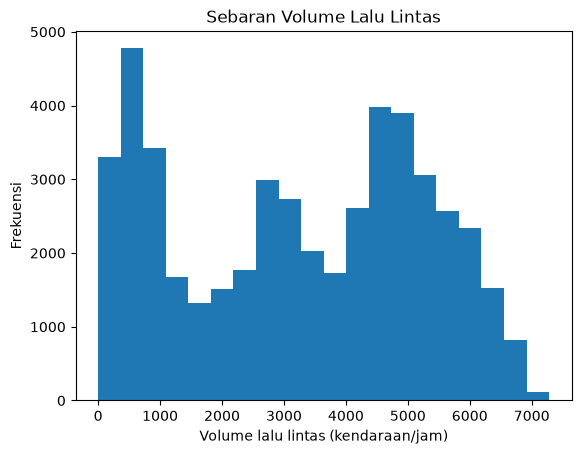

In [58]:
#8 Visualisasi data
import matplotlib.pyplot as plt

plt.hist(df["traffic_volume"], bins=20)
plt.title("Sebaran Volume Lalu Lintas")
plt.xlabel("Volume lalu lintas (kendaraan/jam)")
plt.ylabel("Frekuensi")
plt.show()

Histogram volume lalu lintas menunjukkan pola bimodal (dua puncak). Terlihat sekelompok batang yang sangat tinggi di rentang nilai rendah (kemungkinan mewakili jam-jam dini hari dengan lalu lintas sepi), terpisah dari gerombolan utama data yang terkonsentrasi di rentang nilai menengah-tinggi (kemungkinan jam-jam siang/sore dengan lalu lintas ramai). Pola ini masuk akal karena data mencakup seluruh jam dalam sehari, sehingga menggabungkan dua kondisi lalu lintas yang sangat berbeda karakternya.

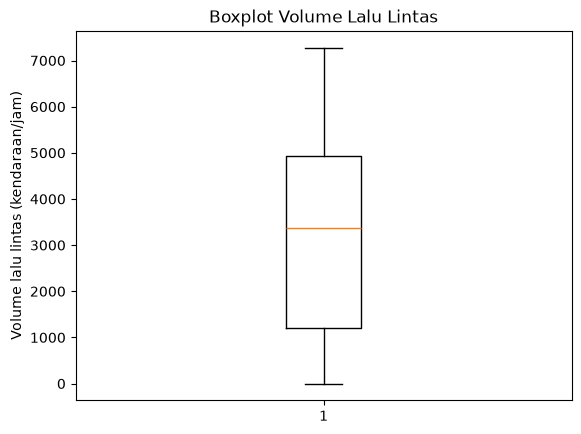

In [56]:
plt.boxplot(df["traffic_volume"])
plt.title("Boxplot Volume Lalu Lintas")
plt.ylabel("Volume lalu lintas (kendaraan/jam)")
plt.show()

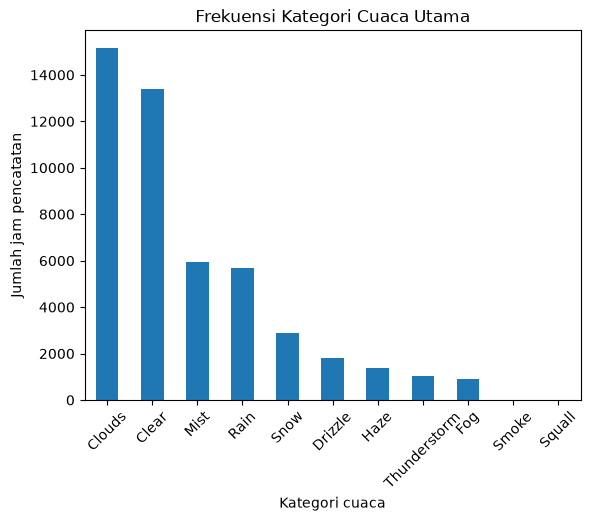

In [57]:
df["weather_main"].value_counts().plot(kind="bar")
plt.title("Frekuensi Kategori Cuaca Utama")
plt.xlabel("Kategori cuaca")
plt.ylabel("Jumlah jam pencatatan")
plt.xticks(rotation=45)
plt.show()

In [53]:
df.groupby("weather_main")["traffic_volume"].median()

weather_main
Clear           3045.5
Clouds          4071.0
Drizzle         3475.0
Fog             2339.0
Haze            3987.0
Mist            2800.0
Rain            3497.0
Smoke           3612.0
Snow            3080.0
Squall          1818.0
Thunderstorm    2969.0
Name: traffic_volume, dtype: float64

#9 Kesimpulan
1. Jawaban pertanyaan (dari latar belakang & pertanyaan)

Pertanyaan 1: Berapa rata-rata dan seberapa besar variasi suhu udara, tutupan awan, dan volume lalu lintas?

Rata-rata suhu udara adalah 281,26 Kelvin (8,1°C) dengan simpangan baku 12,71 K. Rata-rata tutupan awan adalah 49,38% dengan simpangan baku 39,01% (variasi sangat besar). Rata-rata volume lalu lintas adalah 3.259,97 kendaraan/jam dengan simpangan baku 1.986,85 kendaraan/jam. Tutupan awan menunjukkan variasi relatif paling besar di antara ketiganya.

Pertanyaan 2: Apakah sebaran suhu udara dan volume lalu lintas cenderung simetris atau miring ke satu arah?

Suhu udara (temp) menunjukkan pola miring ke kiri (left-skewed), terlihat dari mean (281,26 K) yang lebih kecil dari median (282,46 K), konsisten dengan adanya periode suhu sangat rendah di musim dingin.

Volume lalu lintas (traffic_volume) awalnya tampak miring ke kiri berdasarkan perbandingan mean-median (3.259,97 vs 3.380,00), namun setelah dilihat histogramnya, ternyata sebarannya bimodal (dua puncak), bukan miring ke satu arah. Terdapat kelompok jam dengan volume sangat rendah (kemungkinan dini hari) yang terpisah dari gerombolan utama jam-jam dengan volume menengah-tinggi (jam sibuk). Ini menunjukkan bahwa aturan "bandingkan mean-median" saja tidak cukup untuk menyimpulkan bentuk sebaran tanpa melihat visualisasinya langsung.

2. Temuan paling menarik (3–5)
Ditemukan nilai anomali ekstrem pada rain_1h — 1 baris tercatat 9.831,3 mm curah hujan dalam 1 jam, jauh melampaui rekor dunia (~305 mm), dipastikan kesalahan input data.
Ditemukan 10 baris dengan temp = 0 Kelvin (suhu mutlak nol, mustahil secara fisik), seluruhnya terjadi di jam dini hari pada 2 tanggal spesifik (31 Januari & 2 Februari 2014) — mengindikasikan kegagalan sensor/API cuaca, bukan kesalahan acak.
Ditemukan 7.629 baris dengan date_time yang sama namun kondisi cuaca berbeda, mengindikasikan beberapa laporan cuaca dicatat dalam jam yang sama.
Ketiga variabel numerik utama (temp, clouds_all, traffic_volume) secara konsisten menunjukkan pola miring ke kiri, menunjukkan adanya kecenderungan nilai-nilai rendah ekstrem (musim dingin, langit sangat cerah, jam sepi) yang menarik rata-rata sedikit di bawah median.

4. Keterbatasan data

Dataset ini memiliki keterbatasan sebagai berikut: (1) data hanya berasal dari satu titik sensor tetap di jalan tol I-94, tidak mencerminkan kondisi lalu lintas di lokasi lain, sehingga terkesan kurang luas; (2) ditemukan 28 baris data bermasalah (17 duplikat penuh, 1 nilai curah hujan ekstrem, 10 nilai suhu nol Kelvin) yang harus dibersihkan sebelum analisis; (3) terdapat 7.629 baris dengan waktu pencatatan yang bertumpuk, menandakan inkonsistensi dalam proses pencatatan sistem; (4) periode data (2012–2018) sudah cukup lama dan tidak mencakup kondisi lalu lintas terkini.

. Ide pertanyaan lanjutan

Untuk analisis lanjutan, akan menarik untuk menguji secara statistik (misalnya uji korelasi) apakah tutupan awan atau curah hujan benar-benar berhubungan signifikan dengan volume lalu lintas, mengingat pada Project 1 ini pola tersebut baru diamati secara deskriptif tanpa pengujian formal. Selain itu, dapat dieksplorasi juga apakah terdapat perbedaan pola volume lalu lintas antara hari kerja dan akhir pekan, atau antar musim sepanjang tahun.

## Referensi dan catatan penggunaan AI## Referensi dan Catatan Penggunaan AI

# Sumber Dataset
- Hogue, J. (2019). Metro Interstate Traffic Volume [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5X60B
- Lisensi: [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/legalcode)

# Referensi Belajar
- Dokumentasi resmi pandas: https://pandas.pydata.org/docs/
- Dokumentasi resmi matplotlib: https://matplotlib.org/stable/index.html

# Catatan Penggunaan AI

| Alat | Dipakai untuk | Yang kami pelajari |
|---|---|---|
| Claude | Memilih & memverifikasi kredibilitas dataset | Cara menilai kredibilitas dataset dari sumber, lisensi, dan konsistensi deskripsi |
| Claude | Menanyakan arti error | penyebab dan cara mengatasi berbagai eror |
| Claude | Menanyakan konsep statistik (skala pengukuran, pembagi n-1 varians) | Perbedaan skala nominal/ordinal/interval/rasio, alasan koreksi Bessel |
| Claude | Cross-check interpretasi statistik deskriptif; mengoreksi kesimpulan awal setelah histogram traffic_volume menunjukkan pola bimodal, bukan sekadar miring ringan | Perbandingan mean-median bisa menyesatkan untuk distribusi bimodal; penting melihat histogram, bukan hanya angka ringkasan |
| Claude | Menyarankan teknik `sort_values()` untuk deteksi anomali | Cara mendeteksi outlier selain lewat boxplot |
